<a href="https://colab.research.google.com/github/ekim6535/Final-Project/blob/main/DS340_Final_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Premier League Match Predictor

**DS340 Final Project — Spring 2026**

Machine learning system that predicts Premier League match outcomes and exact scorelines using engineered features beyond standard form-and-xG approaches. Five models are evaluated: Logistic Regression, Random Forest, XGBoost, a Poisson neural network, and a Bet365 bookmaker-odds baseline.

---

# Section 1: Data Collection

## 1.1 Configure Kaggle API and download Transfermarkt data

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!pip install kaggle -q

In [ ]:
!kaggle datasets download -d davidcariboo/player-scores --unzip
!ls

Dataset URL: https://www.kaggle.com/datasets/davidcariboo/player-scores
License(s): CC0-1.0
100% 211M/211M [00:01<00:00, 124MB/s]

appearances.csv   countries.csv     national_teams.csv	   transfers.csv
club_games.csv	  game_events.csv   players.csv
clubs.csv	  game_lineups.csv  player_valuations.csv
competitions.csv  games.csv	    sample_data


## 1.2 Load core Transfermarkt tables

In [ ]:
import pandas as pd

appearances = pd.read_csv("appearances.csv")
players = pd.read_csv("players.csv")
clubs = pd.read_csv("clubs.csv")
games = pd.read_csv("games.csv")

games["date"] = pd.to_datetime(games["date"])
epl_games = games[games["competition_id"] == "GB1"].copy()
print(f"EPL games: {len(epl_games)}, seasons: {sorted(epl_games['season'].unique())}")

EPL games: 5249, seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 1.3 Identify the 20 current Premier League clubs

In [ ]:
current_club_ids = pd.unique(
    epl_games[epl_games["season"].isin([2024, 2025])][["home_club_id", "away_club_id"]].values.ravel()
)
current_clubs = clubs[clubs["club_id"].isin(current_club_ids)][["club_id", "name"]].sort_values("name")
print(current_clubs.to_string(index=False))

 club_id                                   name
      11                  Arsenal Football Club
     989  Association Football Club Bournemouth
     405              Aston Villa Football Club
    1148                Brentford Football Club
    1237 Brighton and Hove Albion Football Club
    1132                  Burnley Football Club
     631                  Chelsea Football Club
     873           Crystal Palace Football Club
      29                  Everton Football Club
     931                   Fulham Football Club
     677                           Ipswich Town
     399 Leeds United Association Football Club
    1003                         Leicester City
      31                Liverpool Football Club
     281          Manchester City Football Club
     985        Manchester United Football Club
     762         Newcastle United Football Club
     703        Nottingham Forest Football Club
     180                         Southampton FC
     289   Sunderland Association Footba

## 1.4 Pull historical match results from football-data.co.uk

Five seasons are pulled because the stadium-records feature (Section 2.4) depends on historical matchups for sample size — most team pairings have only 1-2 meetings per season.

In [ ]:
seasons_urls = {
    "2021-22": "https://www.football-data.co.uk/mmz4281/2122/E0.csv",
    "2022-23": "https://www.football-data.co.uk/mmz4281/2223/E0.csv",
    "2023-24": "https://www.football-data.co.uk/mmz4281/2324/E0.csv",
    "2024-25": "https://www.football-data.co.uk/mmz4281/2425/E0.csv",
    "2025-26": "https://www.football-data.co.uk/mmz4281/2526/E0.csv",
}

fduk = pd.read_csv(seasons_urls["2025-26"])
fduk["Date"] = pd.to_datetime(fduk["Date"], dayfirst=True)
fduk = fduk.sort_values("Date").reset_index(drop=True)

all_matches = []
for season, url in seasons_urls.items():
    df = pd.read_csv(url)
    df["season"] = season
    cols = ["season", "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]
    if season == "2025-26":
        for c in ["B365H", "B365D", "B365A"]:
            if c in df.columns:
                cols.append(c)
    all_matches.append(df[cols])

fduk_all = pd.concat(all_matches, ignore_index=True)
fduk_all["Date"] = pd.to_datetime(fduk_all["Date"], dayfirst=True)
print(f"25/26 matches: {len(fduk)}, total historical matches: {len(fduk_all)}")
fduk.head(3)

25/26 matches: 338, total historical matches: 1858


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,2025-08-16,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,2025-08-16,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08


## 1.5 Pull Understat xG data for 25/26

In [ ]:
!pip install understatapi -q
from understatapi import UnderstatClient

understat = UnderstatClient()
raw = understat.league(league="EPL").get_match_data(season="2025")
xg_df = pd.DataFrame(raw)

# Played matches only (xG is None for unplayed fixtures)
xg_df = xg_df[xg_df["xG"].apply(lambda x: x.get("h") is not None and x.get("a") is not None)].copy()
xg_df["home_team"] = xg_df["h"].apply(lambda x: x["title"])
xg_df["away_team"] = xg_df["a"].apply(lambda x: x["title"])
xg_df["home_xg"] = xg_df["xG"].apply(lambda x: float(x["h"]))
xg_df["away_xg"] = xg_df["xG"].apply(lambda x: float(x["a"]))
xg_df["home_goals"] = xg_df["goals"].apply(lambda x: int(x["h"]))
xg_df["away_goals"] = xg_df["goals"].apply(lambda x: int(x["a"]))
xg_df["date"] = pd.to_datetime(xg_df["datetime"]).dt.date
xg_df = xg_df[["date", "home_team", "away_team", "home_xg", "away_xg", "home_goals", "away_goals"]]
print(f"Played matches: {len(xg_df)}")
xg_df.head(3)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 5.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.1/138.1 kB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
blobfile 3.2.0 requires urllib3>

,date,home_team,away_team,home_xg,away_xg,home_goals,away_goals
0,2025-08-15,Liverpool,Bournemouth,2.330070,1.573030,4,2
1,2025-08-16,Aston Villa,Newcastle United,0.318601,1.400980,0,0
2,2025-08-16,Brighton,Fulham,1.440080,0.902883,1,1


---

# Section 2: Feature Engineering

## 2.1 Squad similarity scoring across seasons

For each current EPL club, computes how similar their 23/24 and 24/25 squads are to today's roster, using minutes-weighted player overlap. The continuous similarity score (range 0–1) is later used in Section 3.9 to gate which historical matches count toward team head-to-head signals.

In [ ]:
def build_squad(club_id, season):
    season_game_ids = epl_games[epl_games["season"] == season]["game_id"]
    squad_apps = appearances[
        (appearances["game_id"].isin(season_game_ids)) &
        (appearances["player_club_id"] == club_id)
    ]
    return (
        squad_apps.groupby("player_id")
        .agg(appearances=("appearance_id", "count"),
             minutes=("minutes_played", "sum"),
             goals=("goals", "sum"),
             assists=("assists", "sum"))
        .reset_index()
        .merge(players[["player_id", "name", "position"]], on="player_id", how="left")
    )

def squad_similarity(squad_a, squad_b):
    players_a = set(squad_a["player_id"])
    players_b = set(squad_b["player_id"])
    common = players_a & players_b
    total_min_a = squad_a["minutes"].sum()
    total_min_b = squad_b["minutes"].sum()
    if total_min_a == 0 or total_min_b == 0:
        return 0.0
    common_min_a = squad_a[squad_a["player_id"].isin(common)]["minutes"].sum()
    common_min_b = squad_b[squad_b["player_id"].isin(common)]["minutes"].sum()
    return (common_min_a / total_min_a + common_min_b / total_min_b) / 2

In [ ]:
target_season = 2025
comparison_seasons = [2023, 2024]
club_ids = current_clubs["club_id"].tolist()

squad_cache = {(cid, s): build_squad(cid, s) for cid in club_ids for s in comparison_seasons + [target_season]}

similarity_records = []
for cid in club_ids:
    club_name = clubs[clubs["club_id"] == cid]["name"].iloc[0]
    for s in comparison_seasons:
        sim = squad_similarity(squad_cache[(cid, s)], squad_cache[(cid, target_season)])
        similarity_records.append({
            "club_id": cid, "club_name": club_name,
            "from_season": s, "to_season": target_season,
            "squad_similarity": sim,
        })

similarity_df = pd.DataFrame(similarity_records)
similarity_df.to_csv("squad_similarity_matrix.csv", index=False)

pivot = similarity_df.pivot_table(index="club_name", columns="from_season",
                                   values="squad_similarity").round(3)
pivot.columns = [f"vs_{c}_{str(c+1)[-2:]}" for c in pivot.columns]
print(pivot.to_string())

                                        vs_2023_24  vs_2024_25
club_name                                                     
Arsenal Football Club                        0.699       0.773
Association Football Club Bournemouth        0.508       0.597
Aston Villa Football Club                    0.733       0.876
Brentford Football Club                      0.507       0.701
Brighton and Hove Albion Football Club       0.512       0.827
Burnley Football Club                        0.219       0.000
Chelsea Football Club                        0.506       0.728
Crystal Palace Football Club                 0.620       0.900
Everton Football Club                        0.596       0.752
Fulham Football Club                         0.633       0.930
Ipswich Town                                 0.000       0.000
Leeds United Association Football Club       0.000       0.000
Leicester City                               0.000       0.000
Liverpool Football Club                      0.711     

## 2.2 Manager head-to-head records

In [ ]:
club_games = pd.read_csv("club_games.csv")
epl_club_games = club_games.merge(epl_games[["game_id", "date", "season"]], on="game_id", how="inner")
epl_club_games["date"] = pd.to_datetime(epl_club_games["date"])

def get_current_manager(club_id, season):
    subset = epl_club_games[
        (epl_club_games["club_id"] == club_id) &
        (epl_club_games["season"] == season)
    ].sort_values("date")
    return subset.iloc[-1]["own_manager_name"] if len(subset) > 0 else None

current_managers = {}
for cid in club_ids:
    club_name = clubs[clubs["club_id"] == cid]["name"].iloc[0]
    mgr = get_current_manager(cid, 2025)
    if mgr:
        current_managers[club_name] = mgr
print(f"{len(current_managers)} current managers")

20 current managers


In [ ]:
all_managers = list(current_managers.values())
h2h_all = club_games[
    (club_games["own_manager_name"].isin(all_managers)) &
    (club_games["opponent_manager_name"].isin(all_managers))
].copy()

def h2h_record(mgr_a, mgr_b):
    matches_subset = h2h_all[
        (h2h_all["own_manager_name"] == mgr_a) &
        (h2h_all["opponent_manager_name"] == mgr_b)
    ]
    if len(matches_subset) == 0:
        return {"wins": 0, "draws": 0, "losses": 0, "n": 0}
    wins = (matches_subset["own_goals"] > matches_subset["opponent_goals"]).sum()
    draws = (matches_subset["own_goals"] == matches_subset["opponent_goals"]).sum()
    losses = (matches_subset["own_goals"] < matches_subset["opponent_goals"]).sum()
    return {"wins": int(wins), "draws": int(draws), "losses": int(losses), "n": len(matches_subset)}

h2h_records = []
for club_a, mgr_a in current_managers.items():
    for club_b, mgr_b in current_managers.items():
        if mgr_a == mgr_b:
            continue
        rec = h2h_record(mgr_a, mgr_b)
        if rec["n"] > 0:
            h2h_records.append({
                "manager_a": mgr_a, "manager_b": mgr_b,
                "matches": rec["n"], "wins_a": rec["wins"], "draws": rec["draws"],
                "ppg_a": round((rec["wins"] * 3 + rec["draws"]) / rec["n"], 2),
            })

h2h_df = pd.DataFrame(h2h_records)
h2h_df.to_csv("manager_h2h_records.csv", index=False)
h2h_df.head()

,manager_a,manager_b,matches,wins_a,draws,ppg_a
0,Mikel Arteta,Andoni Iraola,5,3,0,1.80
1,Mikel Arteta,Unai Emery,9,3,2,1.22
2,Mikel Arteta,Keith Andrews,2,1,1,2.00
3,Mikel Arteta,Fabian Hürzeler,5,3,2,2.20
4,Mikel Arteta,Scott Parker,4,3,1,2.50


## 2.3 Per-team match-level features (form, splits, xG context)

In [ ]:
import numpy as np
from scipy.stats import poisson

home = fduk[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]].rename(
    columns={"HomeTeam": "team", "AwayTeam": "opponent", "FTHG": "gf", "FTAG": "ga"}
)
home["is_home"] = 1
away = fduk[["Date", "AwayTeam", "HomeTeam", "FTAG", "FTHG"]].rename(
    columns={"AwayTeam": "team", "HomeTeam": "opponent", "FTAG": "gf", "FTHG": "ga"}
)
away["is_home"] = 0

team_matches = pd.concat([home, away], ignore_index=True).sort_values(["team", "Date"])
team_matches["result"] = np.where(
    team_matches["gf"] > team_matches["ga"], "W",
    np.where(team_matches["gf"] == team_matches["ga"], "D", "L")
)
team_matches["points"] = team_matches["result"].map({"W": 3, "D": 1, "L": 0})
team_matches.head(3)

,Date,team,opponent,gf,ga,is_home,result,points
346,2025-08-17,Arsenal,Man United,1,0,0,W,3
11,2025-08-23,Arsenal,Leeds,5,0,1,W,3
366,2025-08-31,Arsenal,Liverpool,0,1,0,L,0


### 2.3.1 Rolling form

Predictor: rolling averages of points/goals/conceded over the previous 5 and 10 matches. The `.shift(1)` operation excludes the current match to prevent data leakage.

In [ ]:
def rolling_form(df, n):
    df = df.sort_values(["team", "Date"]).copy()
    for col in ["points", "gf", "ga"]:
        df[f"{col}_last{n}"] = (
            df.groupby("team")[col]
            .transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
        )
    return df

team_matches = rolling_form(team_matches, 5)
team_matches = rolling_form(team_matches, 10)
team_matches[["team", "Date", "points_last5", "gf_last5", "ga_last5"]].head(5)

,team,Date,points_last5,gf_last5,ga_last5
346,Arsenal,2025-08-17,NaN,NaN,NaN
11,Arsenal,2025-08-23,3.00,1.00,0.000000
366,Arsenal,2025-08-31,3.00,3.00,0.000000
31,Arsenal,2025-09-13,2.00,2.00,0.333333
49,Arsenal,2025-09-21,2.25,2.25,0.250000


### 2.3.2 Home/away PPG splits

Predictor: each team's points-per-game when playing at home versus away.

In [ ]:
home_away = team_matches.groupby(["team", "is_home"]).agg(
    played=("Date", "count"), points=("points", "sum"),
).reset_index()
home_away["ppg"] = (home_away["points"] / home_away["played"]).round(2)
home_away.head(6)

,team,is_home,played,points,ppg
0,Arsenal,0,17,32,1.88
1,Arsenal,1,17,41,2.41
2,Aston Villa,0,17,23,1.35
3,Aston Villa,1,17,35,2.06
4,Bournemouth,0,17,22,1.29
5,Bournemouth,1,17,27,1.59


### 2.3.3 Season-level xG context (xG diff and luck)

Predictor: each team's season xG difference and "luck" score (actual points − xPts). Positive luck = overperforming and likely to regress; negative luck = underperforming and likely to improve.

In [ ]:
def expected_points(xg_team, xg_opp, max_goals=10):
    team_probs = [poisson.pmf(k, xg_team) for k in range(max_goals + 1)]
    opp_probs = [poisson.pmf(k, xg_opp) for k in range(max_goals + 1)]
    p_win = sum(team_probs[i] * sum(opp_probs[:i]) for i in range(max_goals + 1))
    p_draw = sum(team_probs[i] * opp_probs[i] for i in range(max_goals + 1))
    return 3 * p_win + 1 * p_draw

xg_df["home_xpts"] = xg_df.apply(lambda r: expected_points(r["home_xg"], r["away_xg"]), axis=1)
xg_df["away_xpts"] = xg_df.apply(lambda r: expected_points(r["away_xg"], r["home_xg"]), axis=1)
xg_df["home_actual_pts"] = xg_df.apply(
    lambda r: 3 if r["home_goals"] > r["away_goals"] else (1 if r["home_goals"] == r["away_goals"] else 0), axis=1)
xg_df["away_actual_pts"] = xg_df.apply(
    lambda r: 3 if r["away_goals"] > r["home_goals"] else (1 if r["away_goals"] == r["home_goals"] else 0), axis=1)

home_agg = xg_df.groupby("home_team").agg(
    xg=("home_xg", "sum"), xga=("away_xg", "sum"),
    xpts=("home_xpts", "sum"), actual_pts=("home_actual_pts", "sum"),
).reset_index().rename(columns={"home_team": "team"})
away_agg = xg_df.groupby("away_team").agg(
    xg=("away_xg", "sum"), xga=("home_xg", "sum"),
    xpts=("away_xpts", "sum"), actual_pts=("away_actual_pts", "sum"),
).reset_index().rename(columns={"away_team": "team"})

total_xg = pd.concat([home_agg, away_agg]).groupby("team").sum().reset_index()
total_xg["xg_diff"] = (total_xg["xg"] - total_xg["xga"]).round(2)
total_xg["luck"] = (total_xg["actual_pts"] - total_xg["xpts"]).round(2)
total_xg = total_xg.round(2).sort_values("xpts", ascending=False).reset_index(drop=True)
total_xg.head(10)

,team,xg,xga,xpts,actual_pts,xg_diff,luck
0,Arsenal,66.83,29.92,67.83,73,36.92,5.17
1,Manchester City,68.96,39.55,63.27,70,29.41,6.73
2,Liverpool,61.06,46.73,56.20,58,14.33,1.80
3,Manchester United,62.48,45.47,55.91,61,17.01,5.09
4,Chelsea,67.43,50.70,54.91,48,16.73,-6.91
5,Bournemouth,60.49,51.52,53.41,49,8.97,-4.41
6,Brentford,60.31,49.17,52.13,48,11.14,-4.13
7,Leeds,53.11,49.44,50.26,40,3.67,-10.26
8,Brighton,51.39,47.03,49.57,50,4.36,0.43
9,Crystal Palace,55.23,48.24,49.23,43,6.99,-6.23


## 2.4 Stadium-specific records with Bayesian shrinkage

Predictor: away team's historical points-per-game at the home team's specific venue. Low-sample matchups (newly promoted teams, rare pairings) are blended toward the league-average away PPG, weighted by sample size — preventing the feature from being either missing or wildly miscalibrated.

In [ ]:
venue_records = []
for (home_team, away_team), group in fduk_all.groupby(["HomeTeam", "AwayTeam"]):
    n = len(group)
    wins = (group["FTAG"] > group["FTHG"]).sum()
    draws = (group["FTAG"] == group["FTHG"]).sum()
    venue_records.append({
        "away_team": away_team, "venue": home_team,
        "matches": n,
        "away_ppg_at_venue": round((wins * 3 + draws) / n, 2),
    })

venue_df = pd.DataFrame(venue_records)
venue_df.to_csv("stadium_records.csv", index=False)
venue_df.sort_values("matches", ascending=False).head(10)

,away_team,venue,matches,away_ppg_at_venue
0,Aston Villa,Arsenal,5,0.8
623,Everton,Wolves,5,1.0
622,Crystal Palace,Wolves,5,2.0
621,Chelsea,Wolves,5,1.4
619,Brighton,Wolves,5,2.6
618,Brentford,Wolves,5,2.0
639,West Ham,Wolves,5,0.6
319,Arsenal,Liverpool,5,0.6
320,Aston Villa,Liverpool,5,0.2
323,Brighton,Liverpool,5,0.4


## 2.5 Position-adjusted player importance and per-match availability

Predictor: `key_player_availability` — fraction of each team's top-5 most important players who appeared in the matchday lineup, ranging from 0 (none played) to 1 (all five played). Importance is computed via a position-aware composite of normalized minutes share, win rate when on field, and goals + assists per 90 minutes.

In [ ]:
epl_2526_ids = epl_games[epl_games["season"] == 2025]["game_id"]
apps_2526 = appearances[appearances["game_id"].isin(epl_2526_ids)].copy()

result_lookup = club_games[["game_id", "club_id", "own_goals", "opponent_goals"]].copy()
result_lookup["team_won"] = (result_lookup["own_goals"] > result_lookup["opponent_goals"]).astype(int)
result_lookup["team_drew"] = (result_lookup["own_goals"] == result_lookup["opponent_goals"]).astype(int)

apps_with_result = apps_2526.merge(
    result_lookup.rename(columns={"club_id": "player_club_id"}),
    on=["game_id", "player_club_id"], how="left"
)
apps_with_result["played"] = (apps_with_result["minutes_played"] > 0).astype(int)

In [ ]:
player_importance = (
    apps_with_result.groupby(["player_club_id", "player_id"])
    .agg(
        minutes=("minutes_played", "sum"),
        apps=("played", "sum"),
        goals=("goals", "sum"),
        assists=("assists", "sum"),
        wins_when_played=("team_won",
            lambda x: x[apps_with_result.loc[x.index, "played"] == 1].sum()),
        draws_when_played=("team_drew",
            lambda x: x[apps_with_result.loc[x.index, "played"] == 1].sum()),
    ).reset_index()
    .merge(players[["player_id", "name", "position"]], on="player_id", how="left")
)

player_importance["ppg_when_played"] = (
    (player_importance["wins_when_played"] * 3 + player_importance["draws_when_played"])
    / player_importance["apps"].replace(0, 1)
).round(2)
player_importance["ga_per_90"] = (
    (player_importance["goals"] + player_importance["assists"]) * 90
    / player_importance["minutes"].replace(0, 1)
).round(2)

MIN_MINUTES = 500
player_importance["meets_threshold"] = player_importance["minutes"] >= MIN_MINUTES
max_possible_min = 33 * 90
player_importance["minutes_share"] = (player_importance["minutes"] / max_possible_min).clip(upper=1)
player_importance["ppg_score"] = (
    player_importance["ppg_when_played"] / 3) * player_importance["meets_threshold"]
player_importance["ga_score"] = (
    player_importance["ga_per_90"].clip(upper=1.0)) * player_importance["meets_threshold"]

def compute_importance(row):
    pos = row["position"]
    m, p, g = row["minutes_share"], row["ppg_score"], row["ga_score"]
    if pos == "Attack":
        return 0.25 * m + 0.20 * p + 0.55 * g
    elif pos == "Midfield":
        return 0.35 * m + 0.30 * p + 0.35 * g
    elif pos == "Defender":
        return 0.50 * m + 0.40 * p + 0.10 * g
    elif pos == "Goalkeeper":
        return 0.60 * m + 0.40 * p
    return 0.40 * m + 0.30 * p + 0.30 * g

player_importance["importance"] = player_importance.apply(compute_importance, axis=1).round(3)
eligible = player_importance[player_importance["meets_threshold"]].copy()

key_players = (
    eligible.sort_values(["player_club_id", "importance"], ascending=[True, False])
    .groupby("player_club_id").head(5)
    .merge(clubs[["club_id", "name"]].rename(columns={"club_id": "player_club_id", "name": "club_name"}),
           on="player_club_id")
)
key_players.to_csv("key_players_per_club.csv", index=False)
key_players[["club_name", "name", "position", "minutes", "ppg_when_played", "ga_per_90", "importance"]].head(10)

,club_name,name,position,minutes,ppg_when_played,ga_per_90,importance
0,Arsenal Football Club,David Raya,Goalkeeper,2790,2.26,0.00,0.865
1,Arsenal Football Club,Jurriën Timber,Defender,2457,2.23,0.33,0.744
2,Arsenal Football Club,Gabriel,Defender,2166,2.28,0.29,0.698
3,Arsenal Football Club,William Saliba,Defender,2075,2.36,0.04,0.668
4,Arsenal Football Club,Declan Rice,Midfield,2585,2.23,0.38,0.661
5,Everton Football Club,Jordan Pickford,Goalkeeper,2790,1.48,0.00,0.761
6,Everton Football Club,James Tarkowski,Defender,2700,1.53,0.07,0.666
7,Everton Football Club,Jake O'Brien,Defender,2549,1.53,0.04,0.637
8,Everton Football Club,Vitaliy Mykolenko,Defender,2331,1.58,0.04,0.607
9,Everton Football Club,James Garner,Midfield,2784,1.48,0.26,0.567


In [ ]:
game_lineups = pd.read_csv("game_lineups.csv")
lineup_lookup = game_lineups.groupby(["game_id", "club_id"])["player_id"].apply(set).to_dict()

def key_players_available(game_id, club_id):
    club_key_ids = set(key_players[key_players["player_club_id"] == club_id]["player_id"])
    if not club_key_ids:
        return None
    lineup = lineup_lookup.get((game_id, club_id), set())
    return round(len(club_key_ids & lineup) / len(club_key_ids), 2)

all_epl_team_games = club_games.merge(epl_games[["game_id", "date", "season"]], on="game_id")
all_epl_team_games["date"] = pd.to_datetime(all_epl_team_games["date"])
all_epl_team_games["key_player_availability"] = all_epl_team_games.apply(
    lambda r: key_players_available(r["game_id"], r["club_id"]), axis=1
)

# Sanity check: pooled across all 25/26 matches, do high-availability matches earn more points?
all_2526 = all_epl_team_games[all_epl_team_games["season"] == 2025].copy()
all_2526["points"] = all_2526.apply(
    lambda r: 3 if r["own_goals"] > r["opponent_goals"]
    else (1 if r["own_goals"] == r["opponent_goals"] else 0), axis=1
)
all_2526["tier"] = pd.cut(all_2526["key_player_availability"],
                          bins=[-0.01, 0.4, 0.7, 1.01],
                          labels=["Low (<40%)", "Medium (40-70%)", "High (>70%)"])
print(all_2526.groupby("tier", observed=True).agg(
    matches=("points", "count"), avg_points=("points", "mean")).round(2))

all_epl_team_games[["game_id", "club_id", "date", "season", "key_player_availability"]].to_csv(
    "key_player_availability.csv", index=False)

/tmp/ipykernel_3315/1874604719.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  game_lineups = pd.read_csv("game_lineups.csv")


                 matches  avg_points
tier                                
Low (<40%)            17        0.88
Medium (40-70%)       38        0.66
High (>70%)          563        1.43


## 2.6 Fatigue feature (days rest across all competitions)

Predictor: days since each team's previous fixture across ALL competitions (including UCL, UEL, FA Cup). Capped at 7 — international breaks beyond a week don't change preparation meaningfully.

In [ ]:
all_games_for_rest = pd.read_csv("games.csv")
all_games_for_rest["date"] = pd.to_datetime(all_games_for_rest["date"])

club_ids_list = current_clubs["club_id"].tolist()
all_games_2526 = all_games_for_rest[
    (all_games_for_rest["season"] == 2025) &
    ((all_games_for_rest["home_club_id"].isin(club_ids_list)) |
     (all_games_for_rest["away_club_id"].isin(club_ids_list)))
].copy()

home_fix = all_games_2526[["game_id", "date", "home_club_id", "competition_id"]].rename(
    columns={"home_club_id": "club_id"})
away_fix = all_games_2526[["game_id", "date", "away_club_id", "competition_id"]].rename(
    columns={"away_club_id": "club_id"})
all_fixtures = pd.concat([home_fix, away_fix]).sort_values(["club_id", "date"]).reset_index(drop=True)

all_fixtures["days_rest_true"] = all_fixtures.groupby("club_id")["date"].diff().dt.days
all_fixtures["days_rest_true"] = all_fixtures["days_rest_true"].clip(upper=7).fillna(7)

pl_only = all_fixtures[all_fixtures["competition_id"] == "GB1"].copy()
pl_only = pl_only.merge(clubs[["club_id", "name"]], on="club_id")
pl_only[["name", "date", "days_rest_true"]].head()

,name,date,days_rest_true
0,Arsenal Football Club,2025-08-17,7.0
1,Arsenal Football Club,2025-08-23,6.0
2,Arsenal Football Club,2025-08-31,7.0
3,Arsenal Football Club,2025-09-13,7.0
4,Arsenal Football Club,2025-09-21,5.0


---

# Section 3: Building the Training Matrix

## 3.1 Standardize team names across data sources

In [ ]:
name_map = {
    "Man City": "Manchester City",
    "Man United": "Manchester United",
    "Nott'm Forest": "Nottingham Forest",
    "Tottenham": "Tottenham Hotspur",
    "Newcastle": "Newcastle United",
    "Wolves": "Wolverhampton Wanderers",
    "Leeds": "Leeds United",
    "Brighton": "Brighton & Hove Albion",
    "West Ham": "West Ham United",
    "Arsenal Football Club": "Arsenal",
    "Manchester City Football Club": "Manchester City",
    "Manchester United Football Club": "Manchester United",
    "Liverpool Football Club": "Liverpool",
    "Chelsea Football Club": "Chelsea",
    "Tottenham Hotspur Football Club": "Tottenham Hotspur",
    "Newcastle United Football Club": "Newcastle United",
    "Aston Villa Football Club": "Aston Villa",
    "Brighton and Hove Albion Football Club": "Brighton & Hove Albion",
    "West Ham United Football Club": "West Ham United",
    "Wolverhampton Wanderers Football Club": "Wolverhampton Wanderers",
    "Nottingham Forest Football Club": "Nottingham Forest",
    "Leeds United Association Football Club": "Leeds United",
    "Burnley Football Club": "Burnley",
    "Sunderland Association Football Club": "Sunderland",
    "Brentford Football Club": "Brentford",
    "Crystal Palace Football Club": "Crystal Palace",
    "Everton Football Club": "Everton",
    "Fulham Football Club": "Fulham",
    "Association Football Club Bournemouth": "Bournemouth",
}

def canon(name):
    return name_map.get(name, name) if not pd.isna(name) else name

xg_df["home_team"] = xg_df["home_team"].map(canon)
xg_df["away_team"] = xg_df["away_team"].map(canon)
team_matches["team"] = team_matches["team"].map(canon)
team_matches["opponent"] = team_matches["opponent"].map(canon)
similarity_df["club_name"] = similarity_df["club_name"].map(canon)
venue_df["away_team"] = venue_df["away_team"].map(canon)
venue_df["venue"] = venue_df["venue"].map(canon)
fduk["HomeTeam"] = fduk["HomeTeam"].map(canon)
fduk["AwayTeam"] = fduk["AwayTeam"].map(canon)
fduk_all["HomeTeam"] = fduk_all["HomeTeam"].map(canon)
fduk_all["AwayTeam"] = fduk_all["AwayTeam"].map(canon)
key_players["club_name"] = key_players["club_name"].map(canon)
total_xg["team"] = total_xg["team"].map(canon)

## 3.2 Initialize match-level base table

In [ ]:
matches = xg_df.copy()
matches["date"] = pd.to_datetime(matches["date"]).dt.normalize()
matches["home_xpts"] = matches.apply(lambda r: expected_points(r["home_xg"], r["away_xg"]), axis=1)
matches["away_xpts"] = matches.apply(lambda r: expected_points(r["away_xg"], r["home_xg"]), axis=1)
print(f"Match-level base: {len(matches)} matches")
matches.head(3)

Match-level base: 339 matches


,date,home_team,away_team,home_xg,away_xg,home_goals,away_goals,home_xpts,away_xpts,home_actual_pts,away_actual_pts
0,2025-08-15,Liverpool,Bournemouth,2.330070,1.573030,4,2,1.836346,0.966685,3,0
1,2025-08-16,Aston Villa,Newcastle United,0.318601,1.400980,0,0,0.515938,2.215582,1,1
2,2025-08-16,Brighton & Hove Albion,Fulham,1.440080,0.902883,1,1,1.755898,0.976223,1,1


## 3.3 Attach rolling form features

In [ ]:
form_cols_keep = ["team", "Date", "points_last5", "gf_last5", "ga_last5",
                  "points_last10", "gf_last10", "ga_last10"]
form = team_matches[form_cols_keep].copy()
form["Date"] = pd.to_datetime(form["Date"]).dt.normalize()

matches = matches.merge(
    form.rename(columns={"team": "home_team", "Date": "date",
        "points_last5": "home_ppg_last5", "gf_last5": "home_gf_last5", "ga_last5": "home_ga_last5",
        "points_last10": "home_ppg_last10", "gf_last10": "home_gf_last10", "ga_last10": "home_ga_last10"}),
    on=["home_team", "date"], how="left"
)
matches = matches.merge(
    form.rename(columns={"team": "away_team", "Date": "date",
        "points_last5": "away_ppg_last5", "gf_last5": "away_gf_last5", "ga_last5": "away_ga_last5",
        "points_last10": "away_ppg_last10", "gf_last10": "away_gf_last10", "ga_last10": "away_ga_last10"}),
    on=["away_team", "date"], how="left"
)
matches[["date", "home_team", "away_team", "home_ppg_last5", "away_ppg_last5"]].head()

,date,home_team,away_team,home_ppg_last5,away_ppg_last5
0,2025-08-15,Liverpool,Bournemouth,NaN,NaN
1,2025-08-16,Aston Villa,Newcastle United,NaN,NaN
2,2025-08-16,Brighton & Hove Albion,Fulham,NaN,NaN
3,2025-08-16,Sunderland,West Ham United,NaN,NaN
4,2025-08-16,Tottenham Hotspur,Burnley,NaN,NaN


## 3.4 Attach season-level xG context

In [ ]:
xg_ctx = total_xg.set_index("team")[["xg_diff", "luck"]].to_dict("index")

matches["home_xg_diff_season"] = matches["home_team"].apply(lambda t: xg_ctx.get(t, {}).get("xg_diff", 0))
matches["away_xg_diff_season"] = matches["away_team"].apply(lambda t: xg_ctx.get(t, {}).get("xg_diff", 0))
matches["home_luck_season"] = matches["home_team"].apply(lambda t: xg_ctx.get(t, {}).get("luck", 0))
matches["away_luck_season"] = matches["away_team"].apply(lambda t: xg_ctx.get(t, {}).get("luck", 0))
matches[["home_team", "away_team", "home_xg_diff_season", "home_luck_season"]].head()

,home_team,away_team,home_xg_diff_season,home_luck_season
0,Liverpool,Bournemouth,14.33,1.80
1,Aston Villa,Newcastle United,-2.04,12.79
2,Brighton & Hove Albion,Fulham,4.36,0.43
3,Sunderland,West Ham United,-18.24,8.87
4,Tottenham Hotspur,Burnley,-11.13,-7.93


## 3.5 Attach key player availability

Adds per-match availability plus two engineered variants: deviation from each team's own season average, and the home-vs-away differential.

In [ ]:
key_avail = pd.read_csv("key_player_availability.csv")
key_avail["date"] = pd.to_datetime(key_avail["date"]).dt.normalize()
key_avail = key_avail.merge(
    key_players[["player_club_id", "club_name"]].drop_duplicates()
    .rename(columns={"player_club_id": "club_id"}),
    on="club_id", how="left"
)
key_avail["club_name"] = key_avail["club_name"].map(canon)
key_lookup = key_avail.set_index(["club_name", "date"])["key_player_availability"].to_dict()

matches["home_key_avail"] = matches.apply(
    lambda r: key_lookup.get((r["home_team"], r["date"]), np.nan), axis=1)
matches["away_key_avail"] = matches.apply(
    lambda r: key_lookup.get((r["away_team"], r["date"]), np.nan), axis=1)

team_avg_home = matches.groupby("home_team")["home_key_avail"].mean().to_dict()
team_avg_away = matches.groupby("away_team")["away_key_avail"].mean().to_dict()
matches["home_key_avail_deviation"] = matches.apply(
    lambda r: (r["home_key_avail"] - team_avg_home.get(r["home_team"], 1.0))
    if pd.notna(r["home_key_avail"]) else 0, axis=1)
matches["away_key_avail_deviation"] = matches.apply(
    lambda r: (r["away_key_avail"] - team_avg_away.get(r["away_team"], 1.0))
    if pd.notna(r["away_key_avail"]) else 0, axis=1)
matches["key_avail_diff"] = (
    matches["home_key_avail"].fillna(1.0) - matches["away_key_avail"].fillna(1.0)
)
matches[["home_team", "home_key_avail", "away_team", "away_key_avail", "key_avail_diff"]].head()

,home_team,home_key_avail,away_team,away_key_avail,key_avail_diff
0,Liverpool,1.0,Bournemouth,1.0,0.0
1,Aston Villa,0.8,Newcastle United,0.8,0.0
2,Brighton & Hove Albion,1.0,Fulham,0.8,0.2
3,Sunderland,0.8,West Ham United,0.8,0.0
4,Tottenham Hotspur,1.0,Burnley,1.0,0.0


## 3.6 Attach stadium-specific records

In [ ]:
LEAGUE_AVG_AWAY_PPG = 1.06
venue_lookup = venue_df.set_index(["away_team", "venue"]).to_dict("index")

def get_venue_ppg(away, home, min_matches=3):
    rec = venue_lookup.get((away, home))
    if rec is None:
        return LEAGUE_AVG_AWAY_PPG
    n, observed = rec["matches"], rec["away_ppg_at_venue"]
    if n >= min_matches:
        return observed
    weight = n / min_matches
    return round(weight * observed + (1 - weight) * LEAGUE_AVG_AWAY_PPG, 2)

matches["away_ppg_at_venue"] = matches.apply(
    lambda r: get_venue_ppg(r["away_team"], r["home_team"]), axis=1)

## 3.7 Attach fatigue (days rest)

In [ ]:
pl_only["name"] = pl_only["name"].map(canon)
pl_only["date"] = pd.to_datetime(pl_only["date"]).dt.normalize()
rest_lookup = pl_only.set_index(["name", "date"])["days_rest_true"].to_dict()

matches["home_days_rest"] = matches.apply(
    lambda r: rest_lookup.get((r["home_team"], r["date"]), 7), axis=1)
matches["away_days_rest"] = matches.apply(
    lambda r: rest_lookup.get((r["away_team"], r["date"]), 7), axis=1)

## 3.8 Attach manager head-to-head features

In [ ]:
mgr_lookup = {canon(t): m for t, m in current_managers.items()}

def get_mgr_h2h(home, away):
    h_mgr, a_mgr = mgr_lookup.get(home), mgr_lookup.get(away)
    if not h_mgr or not a_mgr:
        return {"mgr_h2h_ppg_home": 1.5, "mgr_h2h_n": 0}
    rec = h2h_record(h_mgr, a_mgr)
    if rec["n"] == 0:
        return {"mgr_h2h_ppg_home": 1.5, "mgr_h2h_n": 0}
    return {"mgr_h2h_ppg_home": round((rec["wins"] * 3 + rec["draws"]) / rec["n"], 2),
            "mgr_h2h_n": rec["n"]}

mgr_feats = matches.apply(
    lambda r: pd.Series(get_mgr_h2h(r["home_team"], r["away_team"])), axis=1)
matches = pd.concat([matches, mgr_feats], axis=1)

## 3.9 Attach team head-to-head with squad similarity gating

Past meetings only count if BOTH teams' squads at that time were at least 60% similar to their current squads. The 0.6 threshold treats this as a binary include/exclude decision because partial-similarity meetings between rebuilt teams add more noise than signal.

In [ ]:
SIMILARITY_THRESHOLD = 0.6
sim_to_current = similarity_df[similarity_df["to_season"] == 2025].set_index(
    ["club_name", "from_season"])["squad_similarity"].to_dict()

def squad_sim_to_current(team, season_year):
    if season_year == 2025:
        return 1.0
    return sim_to_current.get((team, season_year), 0.0)

season_year_map = {"2023-24": 2023, "2024-25": 2024}

def historical_h2h(home, away, last_n=5):
    relevant = []
    for season_str, season_year in season_year_map.items():
        if (squad_sim_to_current(home, season_year) < SIMILARITY_THRESHOLD or
            squad_sim_to_current(away, season_year) < SIMILARITY_THRESHOLD):
            continue
        season_games = fduk_all[
            (fduk_all["season"] == season_str) &
            (fduk_all["HomeTeam"] == home) &
            (fduk_all["AwayTeam"] == away)
        ]
        if len(season_games) > 0:
            relevant.append(season_games)
    if not relevant:
        return {"h2h_home_ppg": 1.5, "h2h_n_relevant": 0}
    combined = pd.concat(relevant).tail(last_n)
    home_wins = (combined["FTHG"] > combined["FTAG"]).sum()
    draws = (combined["FTHG"] == combined["FTAG"]).sum()
    return {
        "h2h_home_ppg": round((home_wins * 3 + draws) / len(combined), 2),
        "h2h_n_relevant": len(combined),
    }

team_h2h_feats = matches.apply(
    lambda r: pd.Series(historical_h2h(r["home_team"], r["away_team"])), axis=1)
matches = pd.concat([matches, team_h2h_feats], axis=1)
matches["h2h_home_ppg_weighted"] = (
    matches["h2h_home_ppg"] * matches["h2h_n_relevant"] / 2).fillna(0)
matches["h2h_signal_strength"] = matches["h2h_n_relevant"] / 2
matches[["home_team", "away_team", "h2h_home_ppg", "h2h_n_relevant"]].head(10)

,home_team,away_team,h2h_home_ppg,h2h_n_relevant
0,Liverpool,Bournemouth,1.5,0.0
1,Aston Villa,Newcastle United,1.5,2.0
2,Brighton & Hove Albion,Fulham,3.0,1.0
3,Sunderland,West Ham United,1.5,0.0
4,Tottenham Hotspur,Burnley,1.5,0.0
5,Wolverhampton Wanderers,Manchester City,0.0,1.0
6,Chelsea,Crystal Palace,1.0,1.0
7,Nottingham Forest,Brentford,0.0,1.0
8,Manchester United,Arsenal,1.0,1.0
9,Leeds United,Everton,1.5,0.0


## 3.10 Attach Bet365 odds (used as a baseline benchmark, not as model input)

In [ ]:
odds_table = fduk_all[["Date", "HomeTeam", "AwayTeam", "B365H", "B365D", "B365A"]].copy()
odds_table["Date"] = pd.to_datetime(odds_table["Date"]).dt.normalize()
odds_lookup = odds_table.set_index(["HomeTeam", "AwayTeam", "Date"]).to_dict("index")

def get_odds(home, away, date):
    rec = odds_lookup.get((home, away, date))
    if rec is None or any(pd.isna(rec.get(k)) for k in ["B365H", "B365D", "B365A"]):
        return {"odds_h": np.nan, "odds_d": np.nan, "odds_a": np.nan}
    return {"odds_h": rec["B365H"], "odds_d": rec["B365D"], "odds_a": rec["B365A"]}

odds_feats = matches.apply(
    lambda r: pd.Series(get_odds(r["home_team"], r["away_team"], r["date"])), axis=1)
matches = pd.concat([matches, odds_feats], axis=1)
print(f"Matches with valid odds: {matches['odds_h'].notna().sum()} / {len(matches)}")

Matches with valid odds: 338 / 339


## 3.11 Define target variables

In [ ]:
def result_label(row):
    if pd.isna(row.get("home_goals")) or pd.isna(row.get("away_goals")):
        return np.nan
    if row["home_goals"] > row["away_goals"]:
        return "H"
    if row["home_goals"] == row["away_goals"]:
        return "D"
    return "A"

matches["result"] = matches.apply(result_label, axis=1)
matches["home_goals_target"] = matches["home_goals"]
matches["away_goals_target"] = matches["away_goals"]
print(matches["result"].value_counts())

result
H    143
A    106
D     90
Name: count, dtype: int64


## 3.12 Save the final training matrix

In [ ]:
feature_cols = [
    "date", "home_team", "away_team",
    "home_ppg_last5", "home_gf_last5", "home_ga_last5",
    "home_ppg_last10", "home_gf_last10", "home_ga_last10",
    "away_ppg_last5", "away_gf_last5", "away_ga_last5",
    "away_ppg_last10", "away_gf_last10", "away_ga_last10",
    "home_xg", "away_xg", "home_xpts", "away_xpts",
    "home_xg_diff_season", "away_xg_diff_season",
    "home_luck_season", "away_luck_season",
    "home_key_avail", "away_key_avail",
    "home_key_avail_deviation", "away_key_avail_deviation", "key_avail_diff",
    "away_ppg_at_venue",
    "home_days_rest", "away_days_rest",
    "mgr_h2h_ppg_home", "mgr_h2h_n",
    "h2h_home_ppg", "h2h_n_relevant",
    "h2h_home_ppg_weighted", "h2h_signal_strength",
    "odds_h", "odds_d", "odds_a",
    "home_goals_target", "away_goals_target", "result",
]

training_matrix = matches[feature_cols].copy()
training_matrix.to_csv("training_matrix_full.csv", index=False)
print(f"Shape: {training_matrix.shape}")
training_matrix.head(3)

Shape: (339, 43)


,date,home_team,away_team,home_ppg_last5,home_gf_last5,home_ga_last5,home_ppg_last10,home_gf_last10,home_ga_last10,away_ppg_last5,...,h2h_home_ppg,h2h_n_relevant,h2h_home_ppg_weighted,h2h_signal_strength,odds_h,odds_d,odds_a,home_goals_target,away_goals_target,result
0,2025-08-15,Liverpool,Bournemouth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.5,0.0,0.0,0.0,1.30,6.0,8.5,4,2,H
1,2025-08-16,Aston Villa,Newcastle United,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.5,2.0,1.5,1.0,2.25,3.5,2.9,0,0,D
2,2025-08-16,Brighton & Hove Albion,Fulham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.5,0.5,1.91,3.6,4.0,1,1,D


## 3.13 Correlation analysis

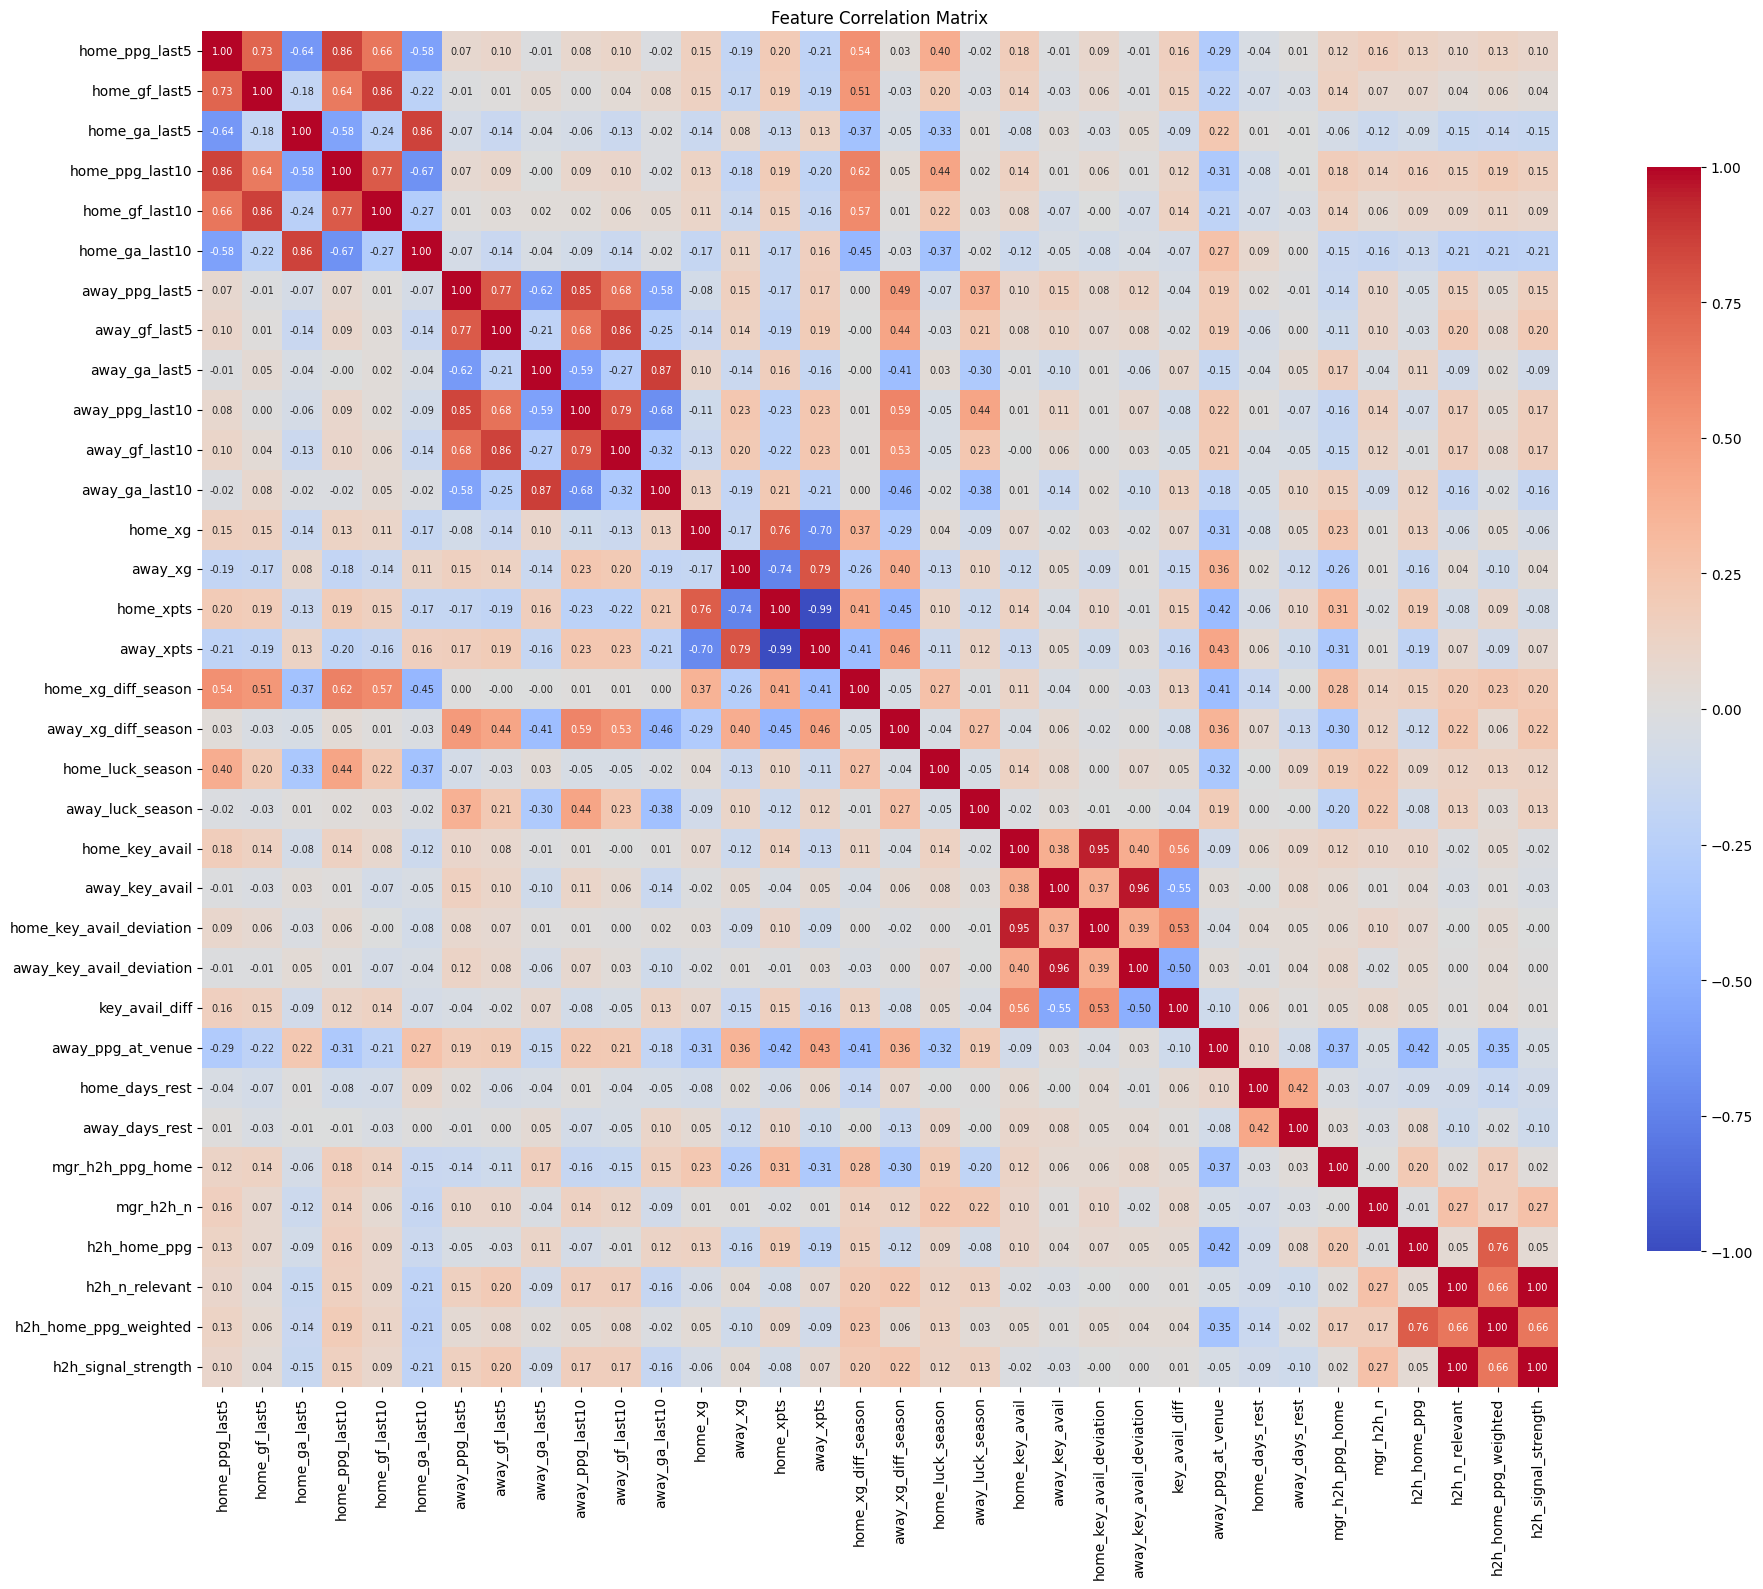

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

exclude_for_corr = ["date", "home_team", "away_team", "result",
                    "home_goals_target", "away_goals_target",
                    "odds_h", "odds_d", "odds_a"]
numeric_feats = [c for c in training_matrix.columns if c not in exclude_for_corr]
corr_matrix = training_matrix[numeric_feats].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=100, bbox_inches="tight")
plt.show()

## 3.14 Feature pruning

Drops features that the correlation matrix above shows are highly redundant: `home_xpts`/`away_xpts` are 0.99 correlated with each other (mathematical mirror image), `last10` form features mirror `last5` form (correlations 0.77–0.86), and the raw `key_avail` columns are 0.86 correlated with their deviation versions.

In [ ]:
features_to_drop = [
    # last10 form duplicates last5 (correlations 0.77-0.86)
    "home_ppg_last10", "home_gf_last10", "home_ga_last10",
    "away_ppg_last10", "away_gf_last10", "away_ga_last10",
    # xpts is 0.99 correlated with itself across home/away (mirror image)
    "home_xpts", "away_xpts",
    # raw key_avail correlates 0.86 with deviation; keep deviation + diff only
    "home_key_avail", "away_key_avail",
    # h2h_home_ppg correlates 0.76 with weighted version
    "h2h_home_ppg",
]

training_matrix_pruned = training_matrix.drop(columns=features_to_drop)
training_matrix_pruned.to_csv("training_matrix_pruned.csv", index=False)
print(f"Original: {training_matrix.shape} → Pruned: {training_matrix_pruned.shape}")

Original: (339, 43) → Pruned: (339, 32)


---

# Section 4: Outcome Classification

The data is split chronologically: the model trains on the first 80% of 25/26 matches and is evaluated on the most recent 20% — matches it has never seen during training. The held-out test set is the standard for "out-of-sample" model evaluation in time-series prediction.

## 4.1 Setup, NaN imputation, and chronological train/test split

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, classification_report
import xgboost as xgb

training_matrix = pd.read_csv("training_matrix_pruned.csv")
training_matrix["date"] = pd.to_datetime(training_matrix["date"])

played = training_matrix[training_matrix["result"].notna()].copy()

form_defaults = {
    "home_ppg_last5": 1.3, "home_gf_last5": 1.4, "home_ga_last5": 1.4,
    "away_ppg_last5": 1.3, "away_gf_last5": 1.4, "away_ga_last5": 1.4,
}
played = played.fillna(form_defaults)
played["home_key_avail_deviation"] = played["home_key_avail_deviation"].fillna(0)
played["away_key_avail_deviation"] = played["away_key_avail_deviation"].fillna(0)
played["key_avail_diff"] = played["key_avail_diff"].fillna(0)

result_map = {"H": 0, "D": 1, "A": 2}
played["result_encoded"] = played["result"].map(result_map)

played = played.sort_values("date").reset_index(drop=True)
split_idx = int(len(played) * 0.8)
train = played.iloc[:split_idx]
test = played.iloc[split_idx:]

feature_cols = [c for c in played.columns if c not in [
    "date", "home_team", "away_team", "result", "result_encoded",
    "home_goals_target", "away_goals_target",
    "odds_h", "odds_d", "odds_a"
]]

X_train, y_train = train[feature_cols], train["result_encoded"]
X_test, y_test = test[feature_cols], test["result_encoded"]

print(f"Train: {len(train)} matches ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {len(test)} matches ({test['date'].min().date()} to {test['date'].max().date()})")

Train: 271 matches (2025-08-15 to 2026-02-23)
Test:  68 matches (2026-02-27 to 2026-04-27)


## 4.2 Logistic Regression

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred)
ll_lr = log_loss(y_test, y_pred_proba)

print(f"Accuracy: {acc_lr:.3f}, Log loss: {ll_lr:.3f}")
print(classification_report(y_test, y_pred, target_names=["Home", "Draw", "Away"]))

Accuracy: 0.618, Log loss: 0.927
              precision    recall  f1-score   support

        Home       0.79      0.76      0.77        29
        Draw       0.38      0.47      0.42        17
        Away       0.63      0.55      0.59        22

    accuracy                           0.62        68
   macro avg       0.60      0.59      0.59        68
weighted avg       0.63      0.62      0.62        68



## 4.3 Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=10,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)
acc_rf = accuracy_score(y_test, y_pred)
ll_rf = log_loss(y_test, y_pred_proba)

print(f"Accuracy: {acc_rf:.3f}, Log loss: {ll_rf:.3f}")
print(classification_report(y_test, y_pred, target_names=["Home", "Draw", "Away"]))

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)
print(importance.head(15).to_string(index=False))

Accuracy: 0.691, Log loss: 0.827
              precision    recall  f1-score   support

        Home       0.71      0.86      0.78        29
        Draw       0.67      0.35      0.46        17
        Away       0.67      0.73      0.70        22

    accuracy                           0.69        68
   macro avg       0.68      0.65      0.65        68
weighted avg       0.69      0.69      0.67        68

                 feature  importance
       away_ppg_at_venue    0.178207
        mgr_h2h_ppg_home    0.128772
                 home_xg    0.088823
                 away_xg    0.083805
     home_xg_diff_season    0.053201
        home_luck_season    0.044615
home_key_avail_deviation    0.041119
away_key_avail_deviation    0.039684
     away_xg_diff_season    0.036901
           home_gf_last5    0.036495
          home_ppg_last5    0.035309
        away_luck_season    0.030544
           home_ga_last5    0.030096
           away_gf_last5    0.027421
          away_ppg_last5    0.0

## 4.3.1 Random Forest Confusion Matrix


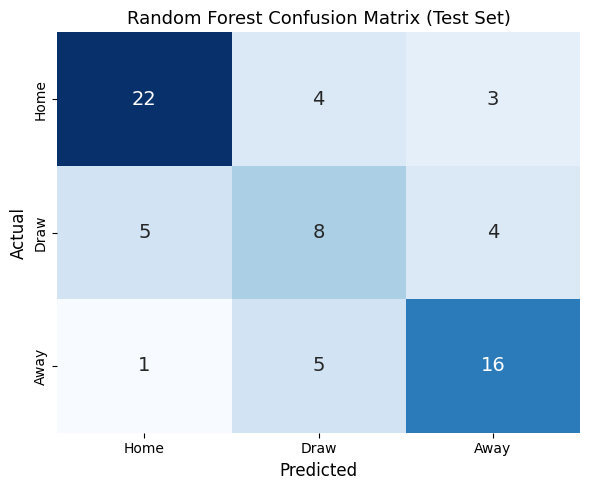

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Home", "Draw", "Away"],
    yticklabels=["Home", "Draw", "Away"],
    cbar=False, annot_kws={"size": 14},
)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Random Forest Confusion Matrix (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.4 XGBoost

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    objective="multi:softprob", num_class=3,
    random_state=42, n_jobs=-1, eval_metric="mlogloss",
)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)
acc_xgb = accuracy_score(y_test, y_pred)
ll_xgb = log_loss(y_test, y_pred_proba)

print(f"Accuracy: {acc_xgb:.3f}, Log loss: {ll_xgb:.3f}")
print(classification_report(y_test, y_pred, target_names=["Home", "Draw", "Away"]))

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)
print(importance.head(15).to_string(index=False))

Accuracy: 0.676, Log loss: 0.941
              precision    recall  f1-score   support

        Home       0.79      0.76      0.77        29
        Draw       0.47      0.47      0.47        17
        Away       0.70      0.73      0.71        22

    accuracy                           0.68        68
   macro avg       0.65      0.65      0.65        68
weighted avg       0.68      0.68      0.68        68

                 feature  importance
       away_ppg_at_venue    0.148196
        mgr_h2h_ppg_home    0.069393
          h2h_n_relevant    0.056549
     home_xg_diff_season    0.054747
          key_avail_diff    0.048982
                 home_xg    0.046571
               mgr_h2h_n    0.046472
                 away_xg    0.044984
away_key_avail_deviation    0.044095
           home_ga_last5    0.043963
          away_ppg_last5    0.041185
          home_ppg_last5    0.037685
           away_gf_last5    0.036390
        away_luck_season    0.034335
          home_days_rest    0.0

## 4.5 Bookmaker odds baseline

Bet365 closing odds converted to implied probabilities (overround removed). The most informative possible baseline because bookmaker odds incorporate huge amounts of information. Beating or matching this is the gold standard for a football prediction model.

In [ ]:
def odds_to_probs(row):
    if pd.isna(row["odds_h"]) or pd.isna(row["odds_d"]) or pd.isna(row["odds_a"]):
        return None
    raw = np.array([1/row["odds_h"], 1/row["odds_d"], 1/row["odds_a"]])
    return raw / raw.sum()

test_with_odds = test[test[["odds_h", "odds_d", "odds_a"]].notna().all(axis=1)].copy()
odds_probs = np.array([odds_to_probs(row) for _, row in test_with_odds.iterrows()])
odds_pred_class = odds_probs.argmax(axis=1)
y_test_odds = test_with_odds["result_encoded"].values

acc_odds = accuracy_score(y_test_odds, odds_pred_class)
ll_odds = log_loss(y_test_odds, odds_probs, labels=[0, 1, 2])

print(f"Test matches with odds: {len(test_with_odds)} / {len(test)}")
print(f"Accuracy: {acc_odds:.3f}, Log loss: {ll_odds:.3f}")
print(classification_report(y_test_odds, odds_pred_class, target_names=["Home", "Draw", "Away"]))

Test matches with odds: 67 / 68
Accuracy: 0.463, Log loss: 1.034
              precision    recall  f1-score   support

        Home       0.46      0.75      0.57        28
        Draw       0.00      0.00      0.00        17
        Away       0.48      0.45      0.47        22

    accuracy                           0.46        67
   macro avg       0.31      0.40      0.34        67
weighted avg       0.35      0.46      0.39        67



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 4.6 Comparison summary

In [ ]:
results = {
    "Logistic Regression": {"accuracy": acc_lr, "log_loss": ll_lr},
    "Random Forest":       {"accuracy": acc_rf, "log_loss": ll_rf},
    "XGBoost":             {"accuracy": acc_xgb, "log_loss": ll_xgb},
    "Bookmaker (Bet365)":  {"accuracy": acc_odds, "log_loss": ll_odds},
}
pd.DataFrame(results).T.round(3)

,accuracy,log_loss
Logistic Regression,0.618,0.927
Random Forest,0.691,0.827
XGBoost,0.676,0.941
Bookmaker (Bet365),0.463,1.034


---

# Section 5: Neural Network for Score Prediction

## 5.1 Setup PyTorch and prepare data

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

training_matrix = pd.read_csv("training_matrix_pruned.csv")
training_matrix["date"] = pd.to_datetime(training_matrix["date"])

played = training_matrix[training_matrix["result"].notna()].copy()
form_defaults = {
    "home_ppg_last5": 1.3, "home_gf_last5": 1.4, "home_ga_last5": 1.4,
    "away_ppg_last5": 1.3, "away_gf_last5": 1.4, "away_ga_last5": 1.4,
}
played = played.fillna(form_defaults)
for c in ["home_key_avail_deviation", "away_key_avail_deviation", "key_avail_diff"]:
    played[c] = played[c].fillna(0)
played = played.sort_values("date").reset_index(drop=True)

feature_cols = [c for c in played.columns if c not in [
    "date", "home_team", "away_team", "result",
    "home_goals_target", "away_goals_target",
    "odds_h", "odds_d", "odds_a"
]]

split_idx = int(len(played) * 0.8)
train_df = played.iloc[:split_idx]
test_df = played.iloc[split_idx:]

X_train = train_df[feature_cols].values.astype(np.float32)
X_test = test_df[feature_cols].values.astype(np.float32)
y_home_train = train_df["home_goals_target"].values.astype(np.float32)
y_away_train = train_df["away_goals_target"].values.astype(np.float32)
y_home_test = test_df["home_goals_target"].values.astype(np.float32)
y_away_test = test_df["away_goals_target"].values.astype(np.float32)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train: {len(train_df)}, Test: {len(test_df)}, Features: {len(feature_cols)}")

Train: 271, Test: 68, Features: 23


## 5.2 Define dataset and dataloader

In [ ]:
class MatchDataset(Dataset):
    def __init__(self, X, y_home, y_away):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_home = torch.tensor(y_home, dtype=torch.float32)
        self.y_away = torch.tensor(y_away, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y_home[idx], self.y_away[idx]

train_ds = MatchDataset(X_train_scaled, y_home_train, y_away_train)
test_ds = MatchDataset(X_test_scaled, y_home_test, y_away_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

## 5.3 Score predictor architecture

In [ ]:
class ScorePredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.home_head = nn.Linear(hidden_dim // 2, 1)
        self.away_head = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        shared = self.shared(x)
        return self.home_head(shared).squeeze(-1), self.away_head(shared).squeeze(-1)

model = ScorePredictor(input_dim=X_train_scaled.shape[1]).to(device)
loss_fn = nn.PoissonNLLLoss(log_input=True, full=True)
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

## 5.4 Training loop with early stopping

Epoch   0  train=2.887  test=2.802
Epoch  10  train=2.430  test=2.802
Epoch  20  train=2.411  test=2.706
Epoch  30  train=2.295  test=2.710
Epoch  40  train=2.316  test=2.736
Epoch  50  train=2.310  test=2.704
Early stopping at epoch 51


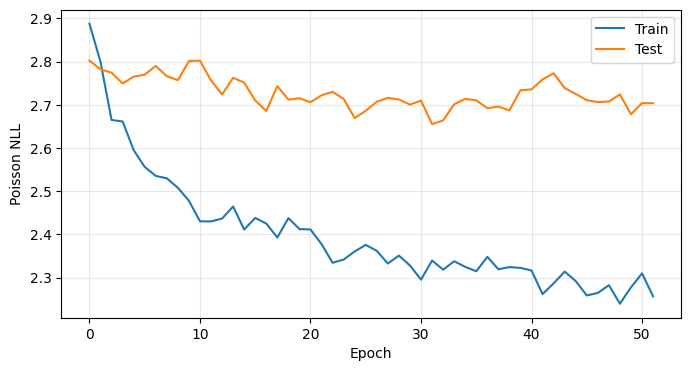

In [ ]:
n_epochs = 200
best_test_loss = float("inf")
best_model_state = None
patience = 20
patience_counter = 0
train_losses, test_losses = [], []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for xb, yh, ya in train_loader:
        xb, yh, ya = xb.to(device), yh.to(device), ya.to(device)
        log_lh, log_la = model(xb)
        loss = loss_fn(log_lh, yh) + loss_fn(log_la, ya)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for xb, yh, ya in test_loader:
            xb, yh, ya = xb.to(device), yh.to(device), ya.to(device)
            log_lh, log_la = model(xb)
            loss = loss_fn(log_lh, yh) + loss_fn(log_la, ya)
            test_loss += loss.item() * len(xb)
    test_loss /= len(test_ds)
    test_losses.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train={epoch_loss:.3f}  test={test_loss:.3f}")

model.load_state_dict(best_model_state)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.xlabel("Epoch"); plt.ylabel("Poisson NLL"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("training_curves.png", dpi=100, bbox_inches="tight"); plt.show()

## 5.5 Evaluation

In [ ]:
model.eval()
all_log_lh, all_log_la = [], []
with torch.no_grad():
    for xb, _, _ in test_loader:
        xb = xb.to(device)
        log_lh, log_la = model(xb)
        all_log_lh.append(log_lh.cpu().numpy())
        all_log_la.append(log_la.cpu().numpy())

lambda_home = np.exp(np.concatenate(all_log_lh))
lambda_away = np.exp(np.concatenate(all_log_la))
predicted_home_goals = np.round(lambda_home).astype(int)
predicted_away_goals = np.round(lambda_away).astype(int)

results = test_df.copy()
results["pred_home_goals"] = predicted_home_goals
results["pred_away_goals"] = predicted_away_goals
results["lambda_home"] = lambda_home.round(2)
results["lambda_away"] = lambda_away.round(2)

exact_score_acc = ((results["pred_home_goals"] == results["home_goals_target"]) &
                   (results["pred_away_goals"] == results["away_goals_target"])).mean()
home_goals_mae = np.abs(results["pred_home_goals"] - results["home_goals_target"]).mean()
away_goals_mae = np.abs(results["pred_away_goals"] - results["away_goals_target"]).mean()

def to_result(h, a):
    return "H" if h > a else ("D" if h == a else "A")
results["pred_result"] = results.apply(
    lambda r: to_result(r["pred_home_goals"], r["pred_away_goals"]), axis=1
)
outcome_acc_nn = (results["pred_result"] == results["result"]).mean()

print(f"Exact score accuracy: {exact_score_acc:.3f}")
print(f"Home goals MAE: {home_goals_mae:.2f}")
print(f"Away goals MAE: {away_goals_mae:.2f}")
print(f"Outcome accuracy (derived): {outcome_acc_nn:.3f}")
results[["home_team", "away_team", "lambda_home", "lambda_away",
         "pred_home_goals", "pred_away_goals",
         "home_goals_target", "away_goals_target", "result", "pred_result"]].head(10)

Exact score accuracy: 0.176
Home goals MAE: 0.74
Away goals MAE: 0.79
Outcome accuracy (derived): 0.603


,home_team,away_team,lambda_home,lambda_away,pred_home_goals,pred_away_goals,home_goals_target,away_goals_target,result,pred_result
271,Wolverhampton Wanderers,Aston Villa,1.68,0.85,2,1,2,0,H,H
272,Bournemouth,Sunderland,1.45,1.19,1,1,1,1,D,D
273,Burnley,Brentford,1.13,1.47,1,1,3,4,A,D
274,Liverpool,West Ham United,2.25,1.14,2,1,5,2,H,H
275,Newcastle United,Everton,1.37,2.24,1,2,2,3,A,A
276,Leeds United,Manchester City,0.72,2.45,1,2,0,1,A,A
277,Arsenal,Chelsea,1.76,0.88,2,1,2,1,H,H
278,Manchester United,Crystal Palace,2.78,0.25,3,0,2,1,H,H
279,Fulham,Tottenham Hotspur,1.46,0.40,1,0,2,1,H,H
280,Brighton & Hove Albion,Nottingham Forest,2.02,0.47,2,0,2,1,H,H


---

# Section 6: Predicting the Next Gameweek (Live Demo)

A live demonstration that runs the trained models on the next round of unplayed fixtures and shows what the system actually predicts. End-of-season runs are noisier than mid-season fixtures because relegation-threatened teams sometimes tank and safe mid-table teams rotate squads, so this section serves as a demo rather than a held-out evaluation. The accuracy numbers reported in Section 4 (test set) and Section 5 (NN evaluation) remain the primary performance metrics.

## 6.1 Pull the next gameweek from Understat

In [ ]:
raw_2526 = understat.league(league="EPL").get_match_data(season="2025")
all_2526 = pd.DataFrame(raw_2526)

unplayed = all_2526[all_2526["xG"].apply(lambda x: x.get("h") is None)].copy()
unplayed["HomeTeam"] = unplayed["h"].apply(lambda x: x["title"]).map(canon)
unplayed["AwayTeam"] = unplayed["a"].apply(lambda x: x["title"]).map(canon)
unplayed["Date"] = pd.to_datetime(unplayed["datetime"]).dt.normalize()

# Take only the next gameweek (earliest unplayed dates)
upcoming_fixtures = unplayed[["Date", "HomeTeam", "AwayTeam"]].sort_values("Date").reset_index(drop=True)
next_gw_date = upcoming_fixtures["Date"].min()
gw_window_end = next_gw_date + pd.Timedelta(days=4)
upcoming_fixtures = upcoming_fixtures[upcoming_fixtures["Date"] <= gw_window_end].reset_index(drop=True)

print(f"Next gameweek: {len(upcoming_fixtures)} fixtures, {next_gw_date.date()} to {gw_window_end.date()}")
upcoming_fixtures.to_string(index=False)

Next gameweek: 10 fixtures, 2026-05-01 to 2026-05-05


'      Date                HomeTeam               AwayTeam\n2026-05-01            Leeds United                Burnley\n2026-05-02               Brentford        West Ham United\n2026-05-02        Newcastle United Brighton & Hove Albion\n2026-05-02 Wolverhampton Wanderers             Sunderland\n2026-05-02                 Arsenal                 Fulham\n2026-05-03             Bournemouth         Crystal Palace\n2026-05-03       Manchester United              Liverpool\n2026-05-03             Aston Villa      Tottenham Hotspur\n2026-05-04                 Chelsea      Nottingham Forest\n2026-05-04                 Everton        Manchester City'

## 6.2 Build the upcoming-features matrix

In [ ]:
def build_upcoming_features(row):
    home, away, date = row["HomeTeam"], row["AwayTeam"], row["Date"]
    home_form = team_matches[team_matches["team"] == home].sort_values("Date").tail(1)
    away_form = team_matches[team_matches["team"] == away].sort_values("Date").tail(1)

    feat = {"date": date, "home_team": home, "away_team": away}

    if len(home_form) > 0:
        feat["home_ppg_last5"] = home_form["points_last5"].iloc[0]
        feat["home_gf_last5"] = home_form["gf_last5"].iloc[0]
        feat["home_ga_last5"] = home_form["ga_last5"].iloc[0]
    else:
        feat.update({"home_ppg_last5": 1.3, "home_gf_last5": 1.4, "home_ga_last5": 1.4})
    if len(away_form) > 0:
        feat["away_ppg_last5"] = away_form["points_last5"].iloc[0]
        feat["away_gf_last5"] = away_form["gf_last5"].iloc[0]
        feat["away_ga_last5"] = away_form["ga_last5"].iloc[0]
    else:
        feat.update({"away_ppg_last5": 1.3, "away_gf_last5": 1.4, "away_ga_last5": 1.4})

    # Per-team season averages as proxies for match-level xG when game hasn't been played
    n_home = max(len(xg_df[xg_df["home_team"] == home]) + len(xg_df[xg_df["away_team"] == home]), 1)
    n_away = max(len(xg_df[xg_df["home_team"] == away]) + len(xg_df[xg_df["away_team"] == away]), 1)
    home_total = xg_ctx.get(home, {})
    away_total = xg_ctx.get(away, {})
    feat["home_xg"] = (total_xg[total_xg["team"] == home]["xg"].iloc[0] / n_home) if (total_xg["team"] == home).any() else 1.4
    feat["away_xg"] = (total_xg[total_xg["team"] == away]["xg"].iloc[0] / n_away) if (total_xg["team"] == away).any() else 1.4

    feat["home_xg_diff_season"] = home_total.get("xg_diff", 0)
    feat["away_xg_diff_season"] = away_total.get("xg_diff", 0)
    feat["home_luck_season"] = home_total.get("luck", 0)
    feat["away_luck_season"] = away_total.get("luck", 0)

    feat["home_key_avail_deviation"] = 0
    feat["away_key_avail_deviation"] = 0
    feat["key_avail_diff"] = 0

    feat["away_ppg_at_venue"] = get_venue_ppg(away, home)
    feat["home_days_rest"] = 7
    feat["away_days_rest"] = 7

    mh2h = get_mgr_h2h(home, away)
    feat["mgr_h2h_ppg_home"] = mh2h["mgr_h2h_ppg_home"]
    feat["mgr_h2h_n"] = mh2h["mgr_h2h_n"]

    th2h = historical_h2h(home, away)
    feat["h2h_n_relevant"] = th2h["h2h_n_relevant"]
    feat["h2h_home_ppg_weighted"] = th2h.get("h2h_home_ppg", 1.5) * th2h["h2h_n_relevant"] / 2
    feat["h2h_signal_strength"] = th2h["h2h_n_relevant"] / 2

    return feat

upcoming_features = pd.DataFrame([build_upcoming_features(row) for _, row in upcoming_fixtures.iterrows()])
upcoming_features.head()

,date,home_team,away_team,home_ppg_last5,home_gf_last5,home_ga_last5,away_ppg_last5,away_gf_last5,away_ga_last5,home_xg,...,away_key_avail_deviation,key_avail_diff,away_ppg_at_venue,home_days_rest,away_days_rest,mgr_h2h_ppg_home,mgr_h2h_n,h2h_n_relevant,h2h_home_ppg_weighted,h2h_signal_strength
0,2026-05-01,Leeds United,Burnley,1.6,1.0,0.4,0.2,0.4,2.2,1.562059,...,0,0,0.71,7,7,0.00,1,0,0.0,0.0
1,2026-05-02,Brentford,West Ham United,1.4,1.6,1.4,1.6,1.2,0.6,1.773824,...,0,0,0.25,7,7,1.00,3,1,0.5,0.5
2,2026-05-02,Newcastle United,Brighton & Hove Albion,1.2,1.2,1.4,2.0,1.4,0.8,1.572353,...,0,0,1.00,7,7,0.25,4,1,0.0,0.5
3,2026-05-02,Wolverhampton Wanderers,Sunderland,1.4,1.2,2.0,1.8,1.4,1.2,0.930000,...,0,0,1.06,7,7,1.50,0,0,0.0,0.0
4,2026-05-02,Arsenal,Fulham,1.8,1.4,1.0,1.0,0.6,0.8,1.965588,...,0,0,0.33,7,7,2.00,7,2,2.0,1.0


## 6.3 Generate predictions

In [ ]:
X_upcoming = upcoming_features[feature_cols].fillna(0).values
xgb_probs = xgb_model.predict_proba(X_upcoming)
xgb_pred_class = xgb_probs.argmax(axis=1)
class_to_label = {0: "H", 1: "D", 2: "A"}

upcoming_features["xgb_pred"] = [class_to_label[c] for c in xgb_pred_class]
upcoming_features["xgb_p_home"] = xgb_probs[:, 0].round(2)
upcoming_features["xgb_p_draw"] = xgb_probs[:, 1].round(2)
upcoming_features["xgb_p_away"] = xgb_probs[:, 2].round(2)

X_upcoming_scaled = scaler.transform(X_upcoming.astype(np.float32))
model.eval()
with torch.no_grad():
    log_lh, log_la = model(torch.tensor(X_upcoming_scaled, dtype=torch.float32).to(device))
    lh = np.exp(log_lh.cpu().numpy())
    la = np.exp(log_la.cpu().numpy())

upcoming_features["nn_pred_score"] = [
    f"{int(np.round(h))}-{int(np.round(a))}" for h, a in zip(lh, la)
]
upcoming_features["nn_lambda_home"] = lh.round(2)
upcoming_features["nn_lambda_away"] = la.round(2)

print(upcoming_features[[
    "date", "home_team", "away_team",
    "xgb_pred", "xgb_p_home", "xgb_p_draw", "xgb_p_away",
    "nn_pred_score", "nn_lambda_home", "nn_lambda_away"
]].to_string(index=False))

upcoming_features.to_csv("upcoming_predictions.csv", index=False)

      date               home_team              away_team xgb_pred  xgb_p_home  xgb_p_draw  xgb_p_away nn_pred_score  nn_lambda_home  nn_lambda_away
2026-05-01            Leeds United                Burnley        D        0.16        0.79        0.05           1-1            1.35            1.11
2026-05-02               Brentford        West Ham United        D        0.40        0.52        0.08           2-1            1.90            0.70
2026-05-02        Newcastle United Brighton & Hove Albion        A        0.07        0.23        0.70           1-1            1.27            1.20
2026-05-02 Wolverhampton Wanderers             Sunderland        D        0.07        0.78        0.15           1-1            0.81            0.89
2026-05-02                 Arsenal                 Fulham        H        0.98        0.01        0.01           1-1            1.07            0.81
2026-05-03             Bournemouth         Crystal Palace        D        0.12        0.72        0.15    